<a href="https://colab.research.google.com/github/VaishaliMJ/Machine_Learning/blob/main/IQR_Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
placementDF=pd.read_csv("placement.csv")

placementDF.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


/tmp/ipython-input-753698497.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placementDF['cgpa'])
/tmp/ipython-input-753698497.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placementDF['placement_exam_marks'])


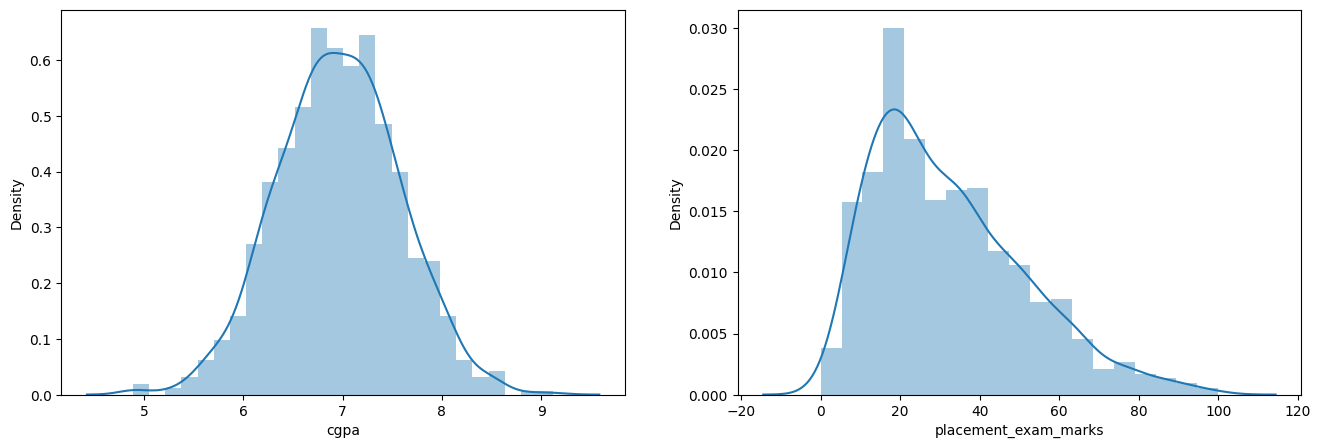

In [4]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(placementDF['cgpa'])

plt.subplot(1,2,2)
sns.distplot(placementDF['placement_exam_marks'])

plt.show()

In [5]:
# Use 'placement_exam_marks' for IQR method
placementDF['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

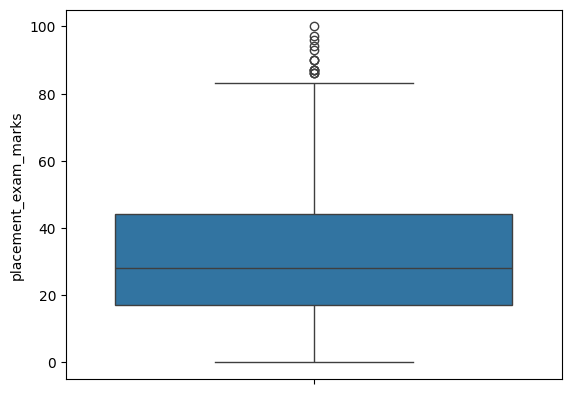

In [6]:
sns.boxplot(placementDF['placement_exam_marks'])

In [10]:
# IQR

Q1=placementDF['placement_exam_marks'].quantile(0.25)
Q3=placementDF['placement_exam_marks'].quantile(0.75)

Q1



np.float64(17.0)

In [11]:
Q3

np.float64(44.0)

In [12]:
IQR=Q3-Q1
IQR

np.float64(27.0)

In [13]:
upperLimit=Q3+1.5*IQR
lowerLimit=Q1-1.5*IQR

upperLimit

np.float64(84.5)

In [14]:
lowerLimit

np.float64(-23.5)

In [17]:
# Outlier Detection

placementDF[(placementDF['placement_exam_marks']>upperLimit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [19]:
placementDF[(placementDF['placement_exam_marks']<lowerLimit)]


,cgpa,placement_exam_marks,placed


In [23]:
# Trimming

newTrimmedDF=placementDF[(placementDF['placement_exam_marks']<upperLimit)]

newTrimmedDF.shape

(985, 3)

/tmp/ipython-input-1176549439.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(placementDF['placement_exam_marks'])
/tmp/ipython-input-1176549439.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(newTrimmedDF['placement_exam_marks'])


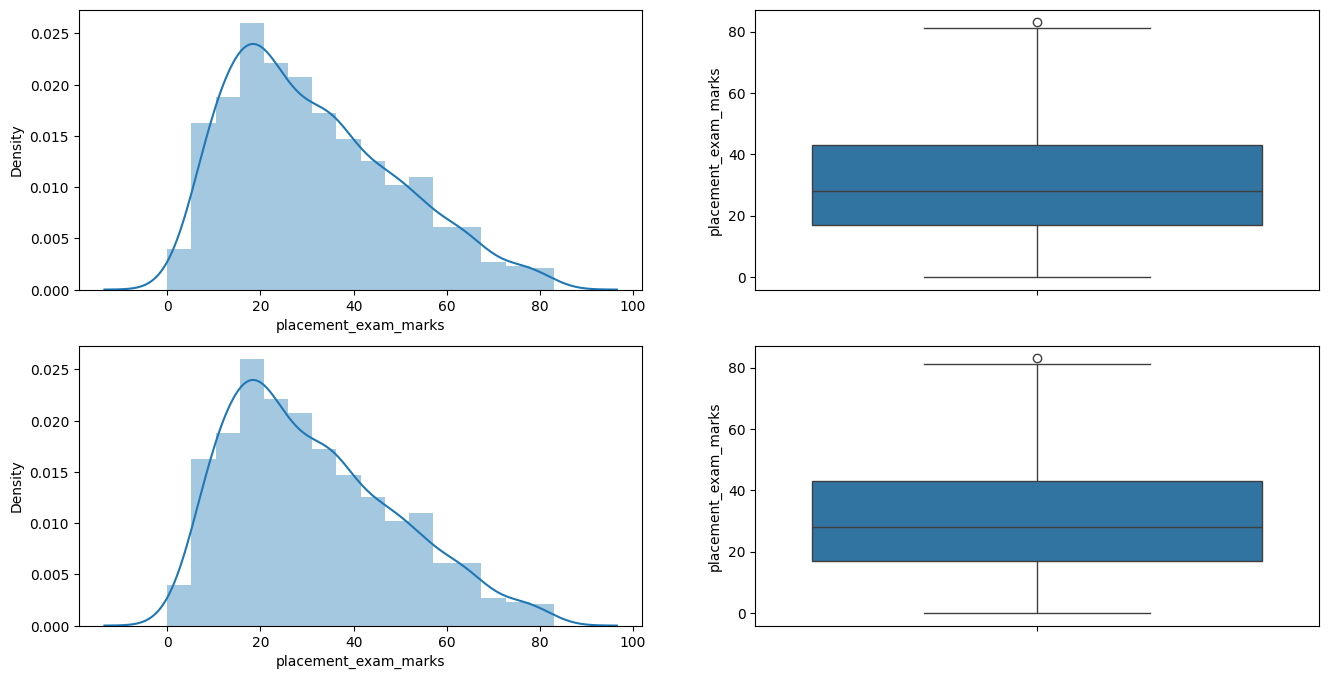

In [24]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(placementDF['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(placementDF['placement_exam_marks'])

plt.subplot(2,2,3)
sns.distplot(newTrimmedDF['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(newTrimmedDF['placement_exam_marks'])

plt.show()

In [25]:
# Capping

newDF=placementDF.copy()
newDF['placement_exam_marks']=np.where(
    newDF['placement_exam_marks']>upperLimit,
    upperLimit,
    np.where(
        newDF['placement_exam_marks']<lowerLimit,
        lowerLimit,
        newDF['placement_exam_marks']
    )
)

newDF.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [26]:
newDF.shape

(985, 3)